In [1]:
!pip install -q shapely scikit-learn matplotlib seaborn pandas numpy requests
print("Dependencies installed.")


Dependencies installed.


In [2]:
import sys, os, zipfile, glob

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import files
    print("Upload raksha_grid_package_live.zip")
    uploaded = files.upload()
    zip_path = list(uploaded.keys())[0]
else:
    zip_path = "raksha_grid_package_live.zip"

EXTRACT_DIR = "/content/raksha_grid" if IN_COLAB else "./raksha_grid"
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(EXTRACT_DIR)

ml_dir_candidates = glob.glob(os.path.join(EXTRACT_DIR, "**", "ml"), recursive=True)
assert ml_dir_candidates, "Could not find an 'ml' folder inside the zip — check the upload."
ML_DIR = os.path.abspath(ml_dir_candidates[0])
sys.path.insert(0, ML_DIR)
os.chdir(ML_DIR)
print("Using ML pipeline from:", ML_DIR)


Upload raksha_grid_package_live.zip


Saving raksha_grid_package_live.zip to raksha_grid_package_live.zip
Using ML pipeline from: /content/raksha_grid/raksha_grid_package_live/ml


In [3]:
import disaster_ml_pipeline as pipe
import state_geo
print("Hazards configured:", list(pipe.HAZARD_FEATURES.keys()))
print("Severity classes:", pipe.SEVERITY_LABELS)


Hazards configured: ['flood', 'landslide', 'avalanche', 'sandstorm', 'cyclone']
Severity classes: ['safe', 'low', 'moderate', 'severe']


In [ ]:
from getpass import getpass

FIRECRAWL_API_KEY = "YOUR API PLEASE"
GROQ_API_KEY = "YOUR API PLEASE"
GROQ_MODEL = "llama-3.3-70b-versatile"

print("Firecrawl configured:", bool(FIRECRAWL_API_KEY))
print("Groq configured:", bool(GROQ_API_KEY))



Firecrawl configured: True
Groq configured: True


In [6]:
import requests, json, re, time

FIRECRAWL_SCRAPE_URL = "https://api.firecrawl.dev/v1/scrape"
GROQ_CHAT_URL = "https://api.groq.com/openai/v1/chat/completions"
GROQ_MODEL = "llama-3.3-70b-versatile"

def firecrawl_scrape(url: str, timeout: int = 30) -> dict | None:
    """Returns {"markdown": str, "title": str, "url": str} or None. Fails soft."""
    if not FIRECRAWL_API_KEY:
        return None
    try:
        resp = requests.post(
            FIRECRAWL_SCRAPE_URL,
            headers={"Authorization": f"Bearer {FIRECRAWL_API_KEY}", "Content-Type": "application/json"},
            json={"url": url, "formats": ["markdown"], "onlyMainContent": True, "timeout": timeout * 1000},
            timeout=timeout,
        )
        resp.raise_for_status()
        payload = resp.json()
        data = payload.get("data", payload)
        markdown = data.get("markdown", "")
        if not markdown:
            return None
        return {
            "markdown": markdown[:20000],
            "title": (data.get("metadata") or {}).get("title", url),
            "url": url,
        }
    except requests.RequestException as e:
        print(f"  [firecrawl] scrape failed for {url}: {e}")
        return None
    except (ValueError, KeyError) as e:
        print(f"  [firecrawl] unexpected response shape for {url}: {e}")
        return None


HISTORICAL_EXTRACTION_PROMPT = """You are a structured-data extractor for an Indian disaster-risk research pipeline.
Given raw text from a government or reference source about India's disaster history, extract every
distinct historical disaster EVENT you can find that is clearly tied to a specific Indian state/UT,
a hazard type, and an approximate year.

Respond with ONLY a JSON array (no prose, no markdown fences). Each element:
{
  "state": "<Indian state/UT name, official name e.g. 'Assam', 'Odisha'>",
  "hazard": "<one of: flood, landslide, avalanche, sandstorm, cyclone>",
  "year": <integer year, best estimate>,
  "severity": "<one of: safe, low, moderate, severe -- judge from deaths/people affected/scale described>",
  "deaths": <integer or null if not stated>,
  "people_affected": <integer or null if not stated>,
  "summary": "<one short sentence, max 20 words>"
}
Only include events tied to hazard types in [flood, landslide, avalanche, sandstorm, cyclone] --
skip earthquakes, epidemics, famines, industrial accidents, heatwaves, and anything not in that list.
If nothing relevant is present, respond with an empty JSON array: []
"""

def groq_extract_events(markdown_text: str, source_url: str) -> list[dict]:
    if GROQ_API_KEY:
        try:
            return _extract_with_groq(markdown_text)
        except Exception as e:
            print(f"  [llm_extract] Groq extraction failed, falling back to keyword scan: {e}")
    return _extract_with_keywords(markdown_text)


def _extract_with_groq(markdown_text: str) -> list[dict]:
    resp = requests.post(
        GROQ_CHAT_URL,
        headers={"Authorization": f"Bearer {GROQ_API_KEY}", "Content-Type": "application/json"},
        json={
            "model": GROQ_MODEL,
            "temperature": 0,
            "max_tokens": 2000,
            "messages": [
                {"role": "system", "content": HISTORICAL_EXTRACTION_PROMPT},
                {"role": "user", "content": markdown_text[:12000]},
            ],
        },
        timeout=30,
    )
    resp.raise_for_status()
    content = resp.json()["choices"][0]["message"]["content"].strip()
    content = re.sub(r"^```(json)?|```$", "", content.strip(), flags=re.MULTILINE).strip()
    events = json.loads(content)
    out = []
    for e in events:
        if not isinstance(e, dict) or "state" not in e or "hazard" not in e:
            continue
        try:
            year = int(e.get("year"))
        except (TypeError, ValueError):
            continue
        severity = str(e.get("severity", "")).strip().lower()
        if severity not in pipe.SEVERITY_LABELS:
            continue
        out.append({
            "state": str(e.get("state", "")).strip(),
            "hazard": str(e.get("hazard", "")).strip().lower(),
            "year": year,
            "severity": severity,
            "deaths": e.get("deaths"),
            "people_affected": e.get("people_affected"),
            "summary": str(e.get("summary", ""))[:200],
            "confidence": 0.8,  # Groq-extracted, grounded in scraped text
        })
    return out


# --- fallback: no Groq key needed, same spirit as backend's keyword scan ---

_ALERT_SEVERITY = [
    (10000, "severe"), (1000, "severe"), (100, "moderate"), (10, "low"), (0, "low"),
]
_HAZARD_WORDS = {
    "flood": ["flood", "river", "inundat", "overflow"],
    "cyclone": ["cyclone", "cyclonic", "storm surge", "depression"],
    "landslide": ["landslide", "slope failure", "mudslide"],
    "avalanche": ["avalanche", "snow slide"],
    "sandstorm": ["sandstorm", "dust storm", "duststorm"],
}
_STATE_NAMES = list(pipe.STATE_HAZARDS.keys())
_YEAR_RE = re.compile(r"\b(19[0-9]{2}|20[0-9]{2})\b")
_DEATH_RE = re.compile(r"([\d,]{2,})\s*(?:people\s+)?(?:were\s+)?(?:killed|dead|died|deaths?)", re.IGNORECASE)

def _severity_from_deaths(deaths: int | None) -> str:
    if not deaths:
        return "low"
    for threshold, label in _ALERT_SEVERITY:
        if deaths >= threshold:
            return label
    return "safe"

def _extract_with_keywords(text: str) -> list[dict]:
    low = text.lower()
    out = []
    for state in _STATE_NAMES:
        if state.lower() not in low:
            continue
        idx = low.find(state.lower())
        window = low[max(0, idx - 400): idx + 400]
        window_orig = text[max(0, idx - 400): idx + 400]
        for hazard, words in _HAZARD_WORDS.items():
            if not any(w in window for w in words):
                continue
            year_match = _YEAR_RE.search(window_orig)
            if not year_match:
                continue
            death_match = _DEATH_RE.search(window_orig)
            deaths = int(death_match.group(1).replace(",", "")) if death_match else None
            out.append({
                "state": state, "hazard": hazard, "year": int(year_match.group(0)),
                "severity": _severity_from_deaths(deaths),
                "deaths": deaths, "people_affected": None,
                "summary": f"Keyword match: '{state}' + {hazard} near {year_match.group(0)} (no LLM key).",
                "confidence": 0.25,
            })
    return out[:15]

print("Scraper + extractor ready.")

Scraper + extractor ready.


In [7]:
SEED_URLS = [
    {"url": "https://ndma.gov.in/Resources/Reports-Studies", "source_type": "government"},
    {"url": "https://ndma.gov.in/en/disaster-data-statistics.html", "source_type": "government"},
    {"url": "https://sdma.kerala.gov.in/notified-disasters/", "source_type": "state_government"},
    {"url": "https://reliefweb.int/disasters?list=India+Disasters&advanced-search=(C119)", "source_type": "international_database"},
    {"url": "https://www.internal-displacement.org/countries/india/", "source_type": "international_database"},
    {"url": "https://www.preventionweb.net/news/indias-policymakers-get-detailed-data-help-manage-disasters", "source_type": "ngo_report"},
    {"url": "https://pmc.ncbi.nlm.nih.gov/articles/PMC9746566/", "source_type": "academic"},
    {"url": "https://en.wikipedia.org/wiki/Category:Natural_disasters_in_India", "source_type": "reference"},
    {"url": "https://en.wikipedia.org/wiki/List_of_natural_disasters_by_death_toll", "source_type": "reference"},
    {"url": "https://en.wikipedia.org/wiki/List_of_Indian_tornadoes", "source_type": "reference"},
    {"url": "https://en.wikipedia.org/wiki/National_Disaster_Management_Authority_(India)", "source_type": "reference"},
]
print(f"{len(SEED_URLS)} seed sources configured.")

11 seed sources configured.


In [8]:
all_events = []
for src in SEED_URLS:
    url = src["url"]
    print(f"Scraping: {url}")
    scraped = firecrawl_scrape(url)
    if scraped is None:
        print("  (no Firecrawl key or scrape failed — using keyword scan requires page text, skipping without a key)")
        # Without Firecrawl we have no page text to scan either — real scraping needs the Firecrawl key.
        continue
    events = groq_extract_events(scraped["markdown"], url)
    for e in events:
        e["source_url"] = url
        e["source_title"] = scraped["title"]
        e["source_type"] = src["source_type"]
    print(f"  -> {len(events)} event(s) extracted")
    all_events.extend(events)
    time.sleep(1)  # be polite to both APIs

import pandas as pd
real_events_df = pd.DataFrame(all_events)
if real_events_df.empty:
    print("\nNo real events scraped (no Firecrawl key entered, or all sources returned nothing).")
    print("The rest of this notebook will fall back to pure-synthetic training —")
    print("re-run this cell after adding a Firecrawl key to get the hybrid comparison.")
else:
    real_events_df = real_events_df.drop_duplicates(subset=["state", "hazard", "year"], keep="first")
    print(f"\n{len(real_events_df)} unique (state, hazard, year) real event records scraped.")
    display(real_events_df.head(20))


Scraping: https://ndma.gov.in/Resources/Reports-Studies
  [firecrawl] scrape failed for https://ndma.gov.in/Resources/Reports-Studies: HTTPSConnectionPool(host='api.firecrawl.dev', port=443): Read timed out. (read timeout=30)
  (no Firecrawl key or scrape failed — using keyword scan requires page text, skipping without a key)
Scraping: https://ndma.gov.in/en/disaster-data-statistics.html
  [firecrawl] scrape failed for https://ndma.gov.in/en/disaster-data-statistics.html: HTTPSConnectionPool(host='api.firecrawl.dev', port=443): Read timed out. (read timeout=30)
  (no Firecrawl key or scrape failed — using keyword scan requires page text, skipping without a key)
Scraping: https://sdma.kerala.gov.in/notified-disasters/
  [llm_extract] Groq extraction failed, falling back to keyword scan: 404 Client Error: Not Found for url: https://api.groq.com/openai/v1/chat/completions
  -> 2 event(s) extracted
Scraping: https://reliefweb.int/disasters?list=India+Disasters&advanced-search=(C119)
  [llm

,state,hazard,year,severity,deaths,people_affected,summary,confidence,source_url,source_title,source_type
0,Kerala,flood,2020,low,NaN,None,Keyword match: 'Kerala' + flood near 2020 (no ...,0.25,https://sdma.kerala.gov.in/notified-disasters/,Notified Disasters - Kerala State Disaster Man...,state_government
1,Kerala,landslide,2020,low,NaN,None,Keyword match: 'Kerala' + landslide near 2020 ...,0.25,https://sdma.kerala.gov.in/notified-disasters/,Notified Disasters - Kerala State Disaster Man...,state_government
2,Himachal Pradesh,flood,1995,low,NaN,None,Keyword match: 'Himachal Pradesh' + flood near...,0.25,https://www.preventionweb.net/news/indias-poli...,India’s policymakers get detailed data to help...,ngo_report
3,Himachal Pradesh,cyclone,1995,low,NaN,None,Keyword match: 'Himachal Pradesh' + cyclone ne...,0.25,https://www.preventionweb.net/news/indias-poli...,India’s policymakers get detailed data to help...,ngo_report
4,Sikkim,flood,1995,low,NaN,None,Keyword match: 'Sikkim' + flood near 1995 (no ...,0.25,https://www.preventionweb.net/news/indias-poli...,India’s policymakers get detailed data to help...,ngo_report
5,Sikkim,cyclone,1995,low,NaN,None,Keyword match: 'Sikkim' + cyclone near 1995 (n...,0.25,https://www.preventionweb.net/news/indias-poli...,India’s policymakers get detailed data to help...,ngo_report
6,Assam,flood,1995,low,NaN,None,Keyword match: 'Assam' + flood near 1995 (no L...,0.25,https://www.preventionweb.net/news/indias-poli...,India’s policymakers get detailed data to help...,ngo_report
7,Assam,cyclone,1995,low,NaN,None,Keyword match: 'Assam' + cyclone near 1995 (no...,0.25,https://www.preventionweb.net/news/indias-poli...,India’s policymakers get detailed data to help...,ngo_report
8,Arunachal Pradesh,flood,1995,low,NaN,None,Keyword match: 'Arunachal Pradesh' + flood nea...,0.25,https://www.preventionweb.net/news/indias-poli...,India’s policymakers get detailed data to help...,ngo_report
9,Arunachal Pradesh,cyclone,1995,low,NaN,None,Keyword match: 'Arunachal Pradesh' + cyclone n...,0.25,https://www.preventionweb.net/news/indias-poli...,India’s policymakers get detailed data to help...,ngo_report


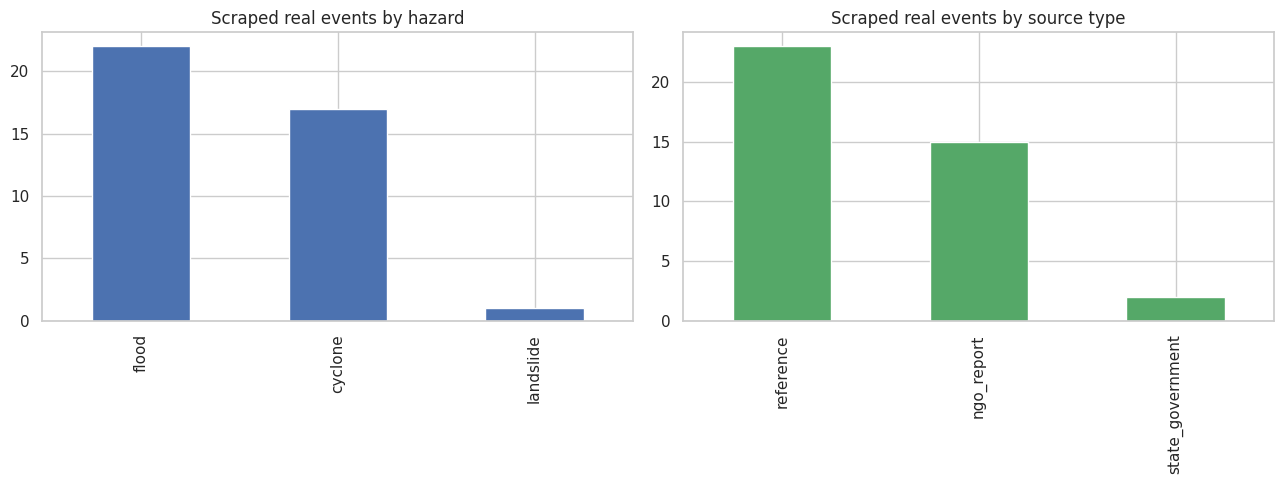

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

if not real_events_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    real_events_df["hazard"].value_counts().plot(kind="bar", ax=axes[0], color="#4C72B0")
    axes[0].set_title("Scraped real events by hazard")
    axes[0].set_xlabel("")

    real_events_df["source_type"].value_counts().plot(kind="bar", ax=axes[1], color="#55A868")
    axes[1].set_title("Scraped real events by source type")
    axes[1].set_xlabel("")

    plt.tight_layout()
    plt.show()
else:
    print("Nothing to plot — no real events scraped this run.")

In [10]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

STATE = "Assam"
HAZARD = "flood"
TEST_YEAR_CUTOFF = 2015

def build_hybrid_history(state: str, hazard: str, events_df: "pd.DataFrame") -> "pd.DataFrame":
    history = pipe.generate_synthetic_history(state, 1925, 2025)
    history = pipe.engineer_features(history, hazard)
    target_col = f"{hazard}_severity"
    history["label_source"] = "synthetic"

    if events_df is not None and not events_df.empty:
        matches = events_df[(events_df.state == state) & (events_df.hazard == hazard)]
        n_matched = 0
        for _, ev in matches.iterrows():
            mask = history["year"] == ev["year"]
            if mask.any():
                history.loc[mask, target_col] = ev["severity"]
                history.loc[mask, "label_source"] = "real_scraped"
                history.loc[mask, "era_weight"] = 1.0  # real label: trust it fully regardless of era
                n_matched += mask.sum()
        print(f"[{state}/{hazard}] matched {len(matches)} real event(s) -> corrected {n_matched} grid-cell-year rows")

    return history

hybrid_history = build_hybrid_history(STATE, HAZARD, real_events_df if not real_events_df.empty else None)
print(hybrid_history["label_source"].value_counts())


[Assam/flood] matched 3 real event(s) -> corrected 309 grid-cell-year rows
label_source
synthetic       10094
real_scraped      309
Name: count, dtype: int64


In [11]:
import time as _time
import warnings
warnings.filterwarnings("ignore")

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    HistGradientBoostingClassifier, RandomForestClassifier, ExtraTreesClassifier,
    GradientBoostingClassifier, VotingClassifier, StackingClassifier,
)
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
)

RANDOM_STATE = 42


In [12]:
def make_split(history_df, hazard):
    target_col = f"{hazard}_severity"
    df = history_df[history_df[target_col].notna()].copy()
    feature_cols = [
        c for c in df.columns
        if c not in ("state", "year", "cell_id", "lat", "lon", target_col, "label_source")
        and pd.api.types.is_numeric_dtype(df[c])
    ]
    train_df = df[df.year < TEST_YEAR_CUTOFF]
    test_df = df[df.year >= TEST_YEAR_CUTOFF]
    le = LabelEncoder().fit(pipe.SEVERITY_LABELS)
    y_train = le.transform(train_df[target_col])
    y_test = le.transform(test_df[target_col])
    sw = train_df["era_weight"].values
    return train_df[feature_cols], test_df[feature_cols], y_train, y_test, sw, feature_cols, le, train_df, test_df

X_train, X_test, y_train, y_test, sample_weight, feature_cols, le, train_df, test_df = make_split(hybrid_history, HAZARD)
print(f"Rows: train={len(X_train)}, test={len(X_test)}, features={len(feature_cols)}")
print(f"Real-labeled rows in train: {(train_df['label_source']=='real_scraped').sum()}, in test: {(test_df['label_source']=='real_scraped').sum()}")

imputer = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=feature_cols, index=X_test.index)

Rows: train=9270, test=1133, features=45
Real-labeled rows in train: 309, in test: 0


In [13]:
def make_models():
    hgb = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.06, max_depth=6, l2_regularization=0.5, random_state=RANDOM_STATE)
    rf = RandomForestClassifier(n_estimators=300, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)
    et = ExtraTreesClassifier(n_estimators=300, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)
    gb = GradientBoostingClassifier(n_estimators=150, learning_rate=0.06, max_depth=4, random_state=RANDOM_STATE)
    lr = LogisticRegression(max_iter=2000)
    voting = VotingClassifier(estimators=[
        ("hgb", HistGradientBoostingClassifier(max_iter=300, learning_rate=0.06, max_depth=6, random_state=RANDOM_STATE)),
        ("rf", RandomForestClassifier(n_estimators=200, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)),
        ("et", ExtraTreesClassifier(n_estimators=200, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)),
    ], voting="soft", n_jobs=-1)
    stacking = StackingClassifier(estimators=[
        ("hgb", HistGradientBoostingClassifier(max_iter=200, learning_rate=0.06, max_depth=6, random_state=RANDOM_STATE)),
        ("rf", RandomForestClassifier(n_estimators=150, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)),
        ("et", ExtraTreesClassifier(n_estimators=150, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)),
    ], final_estimator=LogisticRegression(max_iter=2000), n_jobs=-1)

    return {
        "HistGradientBoosting (production)": (hgb, "raw"),
        "RandomForest": (rf, "imputed"),
        "ExtraTrees": (et, "imputed"),
        "GradientBoosting (sklearn exact)": (gb, "imputed"),
        "LogisticRegression (baseline)": (lr, "imputed"),
        "VotingEnsemble (soft)": (voting, "imputed"),
        "StackingEnsemble": (stacking, "imputed"),
    }

models = make_models()
print("Models to compare:", list(models.keys()))

Models to compare: ['HistGradientBoosting (production)', 'RandomForest', 'ExtraTrees', 'GradientBoosting (sklearn exact)', 'LogisticRegression (baseline)', 'VotingEnsemble (soft)', 'StackingEnsemble']


In [14]:
def evaluate(name, model, data_mode):
    Xtr, Xte = (X_train, X_test) if data_mode == "raw" else (X_train_imp, X_test_imp)
    t0 = _time.time()
    try:
        model.fit(Xtr, y_train, sample_weight=sample_weight)
    except TypeError:
        model.fit(Xtr, y_train)
    train_time = _time.time() - t0
    preds = model.predict(Xte)
    result = {
        "model": name,
        "accuracy": accuracy_score(y_test, preds),
        "precision_macro": precision_score(y_test, preds, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, preds, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test, preds, average="macro", zero_division=0),
        "train_time_sec": train_time,
    }
    try:
        proba = model.predict_proba(Xte)
        result["roc_auc_ovr_macro"] = roc_auc_score(y_test, proba, multi_class="ovr", average="macro", labels=range(len(le.classes_)))
    except Exception:
        result["roc_auc_ovr_macro"] = np.nan
    return result, preds, model

rows, preds_by_model, fitted_models = [], {}, {}
for name, (model, mode) in models.items():
    print(f"Training {name} ...")
    res, preds, fitted = evaluate(name, model, mode)
    rows.append(res)
    preds_by_model[name] = preds
    fitted_models[name] = (fitted, mode)

results_df = pd.DataFrame(rows).sort_values("f1_macro", ascending=False).reset_index(drop=True)
results_df.round(3)


Training HistGradientBoosting (production) ...
Training RandomForest ...
Training ExtraTrees ...
Training GradientBoosting (sklearn exact) ...
Training LogisticRegression (baseline) ...
Training VotingEnsemble (soft) ...
Training StackingEnsemble ...


,model,accuracy,precision_macro,recall_macro,f1_macro,train_time_sec,roc_auc_ovr_macro
0,ExtraTrees,0.786,0.854,0.735,0.774,2.044,0.969
1,LogisticRegression (baseline),0.780,0.834,0.682,0.728,27.811,0.954
2,StackingEnsemble,0.693,0.813,0.536,0.578,65.599,0.956
3,RandomForest,0.659,0.796,0.521,0.565,12.649,0.958
4,VotingEnsemble (soft),0.635,0.795,0.509,0.550,20.465,0.957
5,HistGradientBoosting (production),0.632,0.783,0.508,0.549,12.800,0.866
6,GradientBoosting (sklearn exact),0.632,0.764,0.507,0.545,143.308,0.847


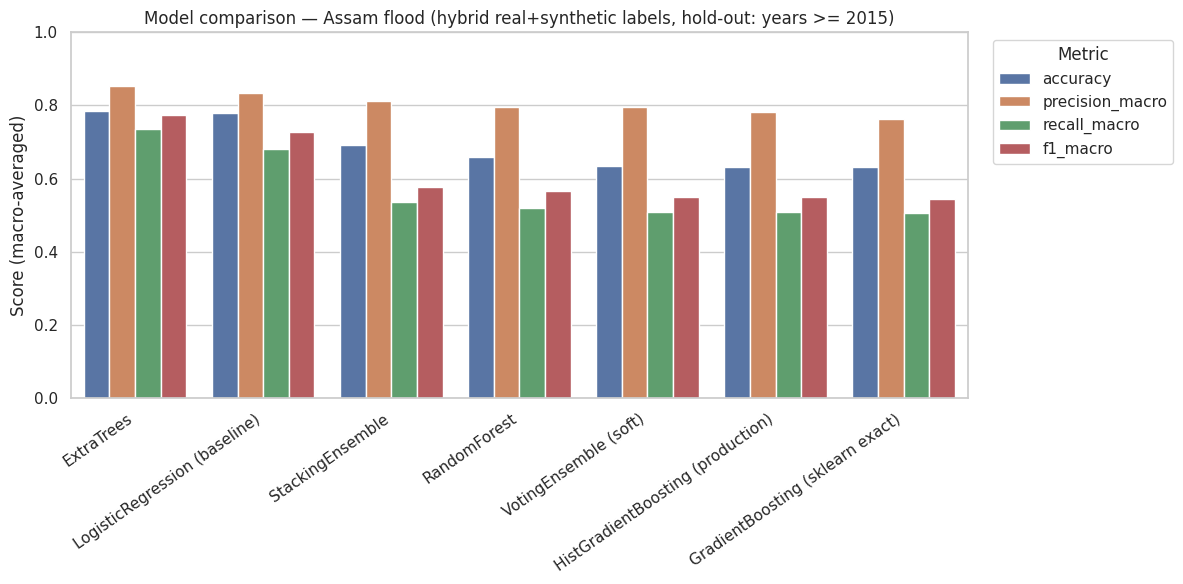

In [15]:
metrics_to_plot = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]
plot_df = results_df.melt(id_vars="model", value_vars=metrics_to_plot, var_name="metric", value_name="score")

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="model", y="score", hue="metric")
plt.xticks(rotation=35, ha="right")
plt.ylim(0, 1)
plt.title(f"Model comparison — {STATE} {HAZARD} (hybrid real+synthetic labels, hold-out: years >= {TEST_YEAR_CUTOFF})")
plt.ylabel("Score (macro-averaged)")
plt.xlabel("")
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

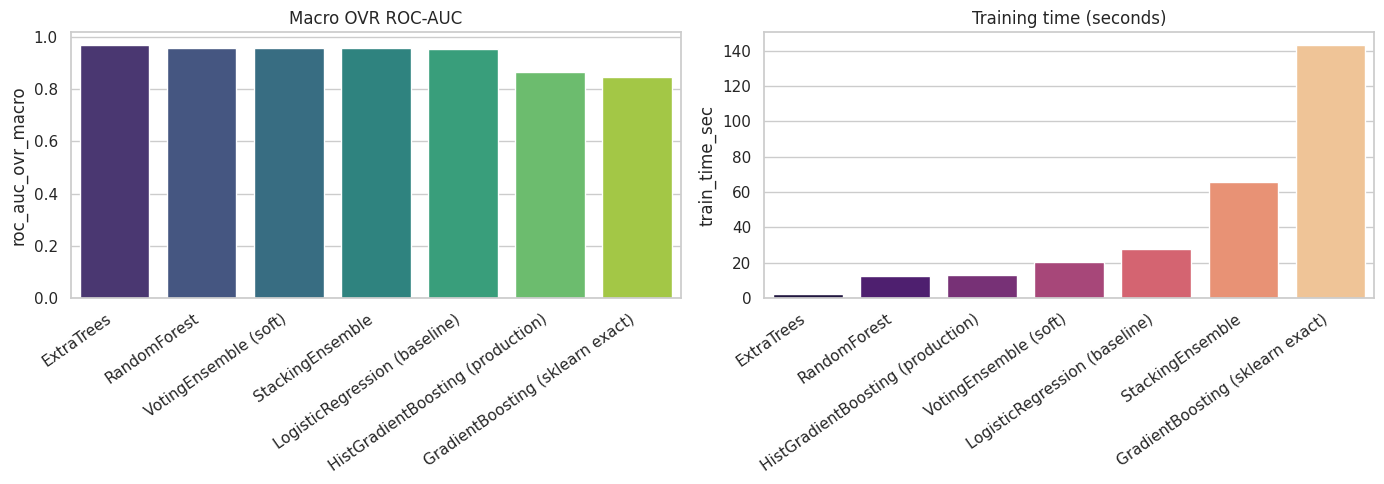

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=results_df.sort_values("roc_auc_ovr_macro", ascending=False), x="model", y="roc_auc_ovr_macro", ax=axes[0], palette="viridis")
axes[0].set_title("Macro OVR ROC-AUC")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=35)
for t in axes[0].get_xticklabels(): t.set_ha("right")

sns.barplot(data=results_df.sort_values("train_time_sec"), x="model", y="train_time_sec", ax=axes[1], palette="magma")
axes[1].set_title("Training time (seconds)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=35)
for t in axes[1].get_xticklabels(): t.set_ha("right")

plt.tight_layout()
plt.show()


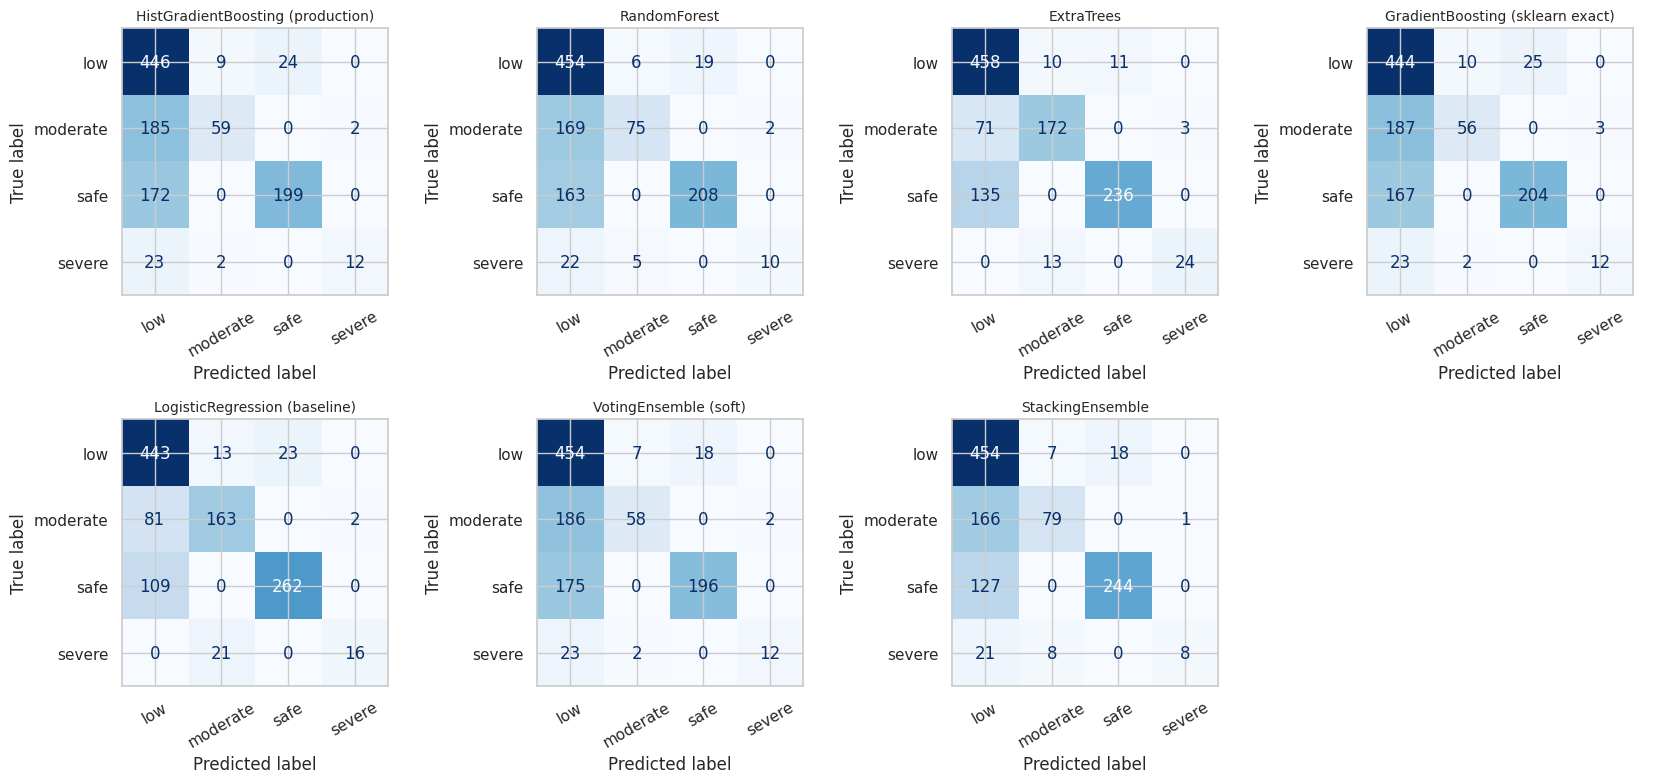

In [17]:
n_models = len(fitted_models)
n_cols = 4
n_rows = int(np.ceil(n_models / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, (name, preds) in zip(axes, preds_by_model.items()):
    cm = confusion_matrix(y_test, preds, labels=range(len(le.classes_)))
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap="Blues", values_format="d")
    ax.set_title(name, fontsize=10)
    ax.tick_params(axis="x", rotation=30)

for ax in axes[n_models:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

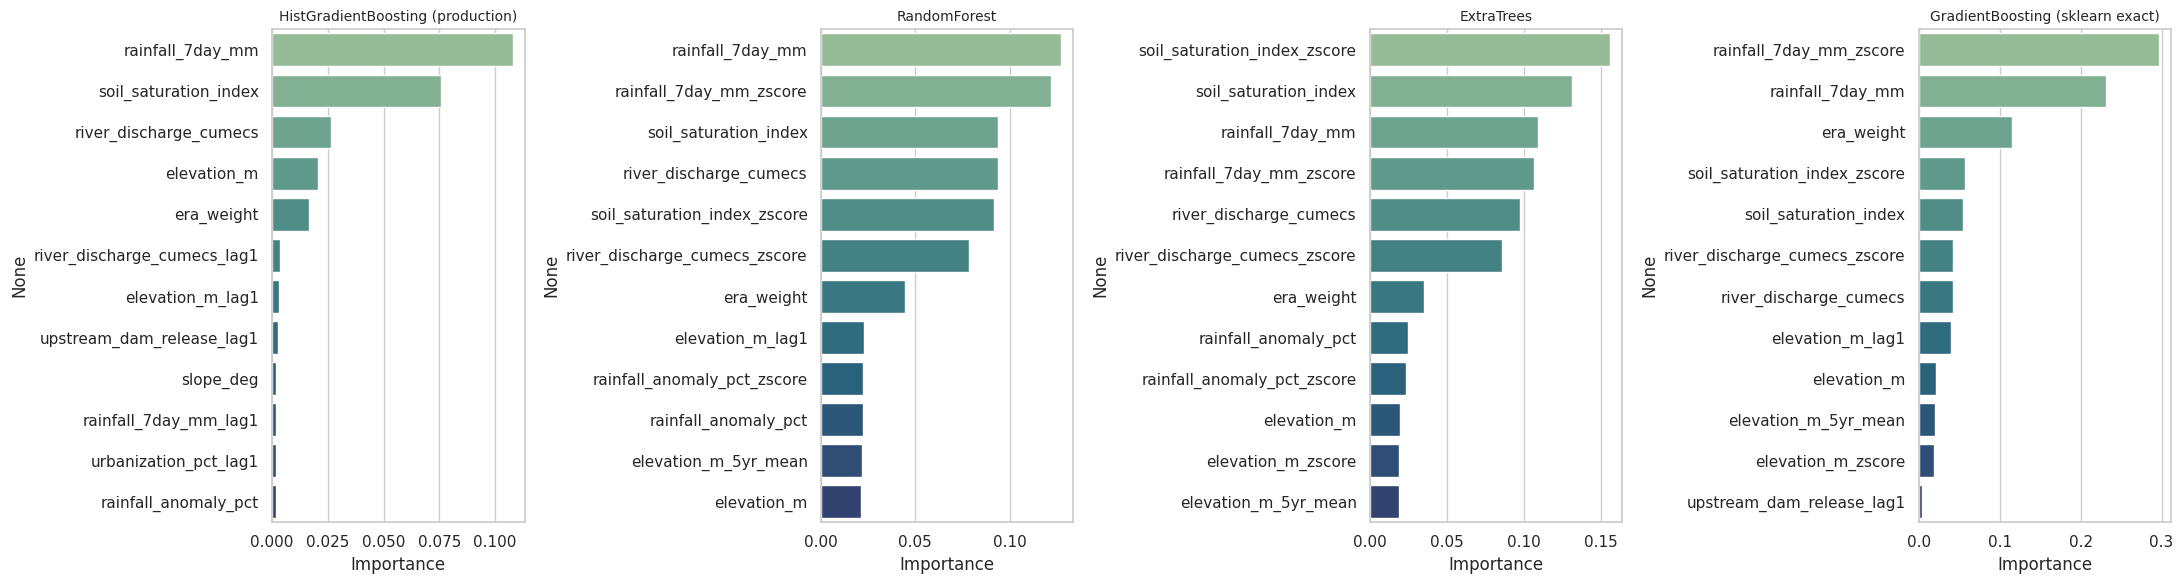

In [18]:
top_n = 12

def get_importance(name):
    model, mode = fitted_models[name]
    Xte = X_test if mode == "raw" else X_test_imp
    if hasattr(model, "feature_importances_"):
        imp = pd.Series(model.feature_importances_, index=feature_cols)
    else:
        r = permutation_importance(model, Xte, y_test, n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
        imp = pd.Series(r.importances_mean, index=feature_cols)
    return imp.sort_values(ascending=False).head(top_n)

importance_models = ["HistGradientBoosting (production)", "RandomForest", "ExtraTrees", "GradientBoosting (sklearn exact)"]
importance_models = [m for m in importance_models if m in fitted_models]

fig, axes = plt.subplots(1, len(importance_models), figsize=(5.5 * len(importance_models), 6))
if len(importance_models) == 1:
    axes = [axes]
for ax, name in zip(axes, importance_models):
    imp = get_importance(name)
    sns.barplot(x=imp.values, y=imp.index, ax=ax, palette="crest")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()


,model,f1_macro_synthetic_only,f1_macro_hybrid,delta
0,HistGradientBoosting (production),0.797,0.549,-0.248
1,RandomForest,0.792,0.565,-0.227
2,ExtraTrees,0.802,0.774,-0.028
3,GradientBoosting (sklearn exact),0.795,0.545,-0.250
4,LogisticRegression (baseline),0.746,0.728,-0.017
5,VotingEnsemble (soft),0.795,0.550,-0.245
6,StackingEnsemble,0.805,0.578,-0.227


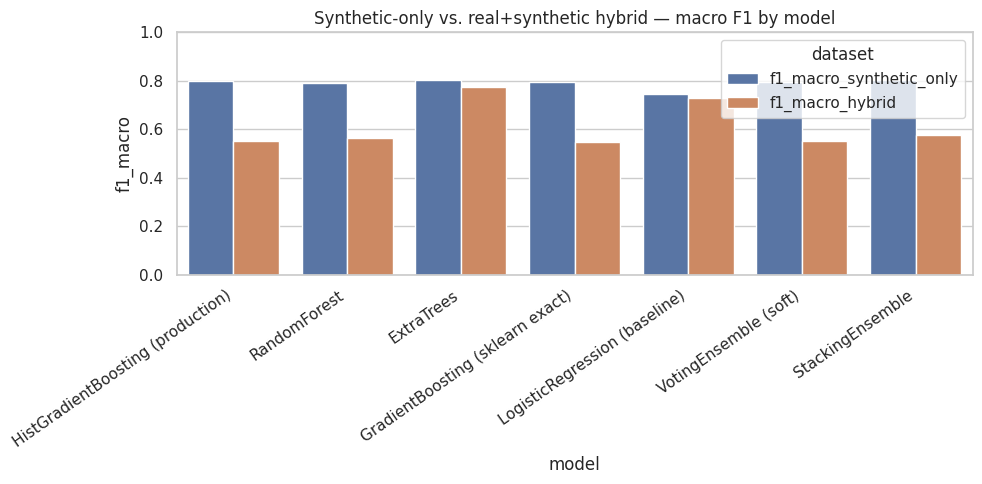

In [19]:
synthetic_only_history = pipe.generate_synthetic_history(STATE, HAZARD if False else STATE, 1925, 2025) if False else None
synthetic_only_history = pipe.generate_synthetic_history(STATE, 1925, 2025)
synthetic_only_history = pipe.engineer_features(synthetic_only_history, HAZARD)
synthetic_only_history["label_source"] = "synthetic"

Xtr_s, Xte_s, ytr_s, yte_s, sw_s, fcols_s, le_s, _, _ = make_split(synthetic_only_history, HAZARD)
imp_s = SimpleImputer(strategy="median")
Xtr_s_imp = pd.DataFrame(imp_s.fit_transform(Xtr_s), columns=fcols_s)
Xte_s_imp = pd.DataFrame(imp_s.transform(Xte_s), columns=fcols_s)

compare_rows = []
for name, (model, mode) in make_models().items():
    Xtr_, Xte_ = (Xtr_s, Xte_s) if mode == "raw" else (Xtr_s_imp, Xte_s_imp)
    try:
        model.fit(Xtr_, ytr_s, sample_weight=sw_s)
    except TypeError:
        model.fit(Xtr_, ytr_s)
    preds = model.predict(Xte_)
    compare_rows.append({
        "model": name,
        "f1_macro_synthetic_only": f1_score(yte_s, preds, average="macro", zero_division=0),
        "f1_macro_hybrid": results_df.set_index("model").loc[name, "f1_macro"] if name in results_df["model"].values else np.nan,
    })

compare_df = pd.DataFrame(compare_rows)
compare_df["delta"] = compare_df["f1_macro_hybrid"] - compare_df["f1_macro_synthetic_only"]
display(compare_df.round(3))

plt.figure(figsize=(10, 5))
plot_compare = compare_df.melt(id_vars="model", value_vars=["f1_macro_synthetic_only", "f1_macro_hybrid"], var_name="dataset", value_name="f1_macro")
sns.barplot(data=plot_compare, x="model", y="f1_macro", hue="dataset")
plt.xticks(rotation=35, ha="right")
plt.title("Synthetic-only vs. real+synthetic hybrid — macro F1 by model")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

if real_events_df.empty:
    print("\nNote: no real events were scraped this run (no Firecrawl key), so hybrid == synthetic-only above.")
    print("Add a Firecrawl key and re-run from Section 6 to see the real effect.")


In [21]:
STATE_HAZARD_COMBOS = [
    ("Assam", "flood"),
    ("Rajasthan", "sandstorm"),
    ("Kerala", "flood"),
    ("Odisha", "cyclone"),
    ("Himachal Pradesh", "landslide"),
]
STABILITY_MODELS = ["HistGradientBoosting (production)", "RandomForest", "ExtraTrees", "VotingEnsemble (soft)"]

stability_rows = []
for state, hazard in STATE_HAZARD_COMBOS:
    print(f"--- {state} / {hazard} ---")
    h = build_hybrid_history(state, hazard, real_events_df if not real_events_df.empty else None)
    Xtr_h, Xte_h, ytr_h, yte_h, sw_h, fcols_h, le_h, tr_h, te_h = make_split(h, hazard)
    if len(Xtr_h) == 0 or len(Xte_h) == 0:
        print(f"  skipping {state}/{hazard} — not enough rows on one side of the split")
        continue
    imp_h = SimpleImputer(strategy="median")
    Xtr_h_imp = pd.DataFrame(imp_h.fit_transform(Xtr_h), columns=fcols_h)
    Xte_h_imp = pd.DataFrame(imp_h.transform(Xte_h), columns=fcols_h)

    local_models = make_models()
    for name in STABILITY_MODELS:
        model, mode = local_models[name]
        Xtr_, Xte_ = (Xtr_h, Xte_h) if mode == "raw" else (Xtr_h_imp, Xte_h_imp)
        try:
            model.fit(Xtr_, ytr_h, sample_weight=sw_h)
        except TypeError:
            model.fit(Xtr_, ytr_h)
        preds = model.predict(Xte_)
        stability_rows.append({
            "state": state, "hazard": hazard, "model": name,
            "accuracy": accuracy_score(yte_h, preds),
            "f1_macro": f1_score(yte_h, preds, average="macro", zero_division=0),
            "real_labeled_rows": int((tr_h["label_source"] == "real_scraped").sum() + (te_h["label_source"] == "real_scraped").sum()),
        })

stability_df = pd.DataFrame(stability_rows)
stability_df


--- Assam / flood ---
[Assam/flood] matched 3 real event(s) -> corrected 309 grid-cell-year rows
--- Rajasthan / sandstorm ---
[Rajasthan/sandstorm] matched 0 real event(s) -> corrected 0 grid-cell-year rows
--- Kerala / flood ---
[Kerala/flood] matched 1 real event(s) -> corrected 99 grid-cell-year rows
--- Odisha / cyclone ---
[Odisha/cyclone] matched 1 real event(s) -> corrected 0 grid-cell-year rows
--- Himachal Pradesh / landslide ---
[Himachal Pradesh/landslide] matched 0 real event(s) -> corrected 0 grid-cell-year rows


,state,hazard,model,accuracy,f1_macro,real_labeled_rows
0,Assam,flood,HistGradientBoosting (production),0.632833,0.453761,309
1,Assam,flood,RandomForest,0.654898,0.466261,309
2,Assam,flood,ExtraTrees,0.806708,0.771746,309
3,Assam,flood,VotingEnsemble (soft),0.644307,0.461632,309
4,Rajasthan,sandstorm,HistGradientBoosting (production),0.822804,0.664764,0
5,Rajasthan,sandstorm,RandomForest,0.826400,0.619666,0
6,Rajasthan,sandstorm,ExtraTrees,0.824345,0.575162,0
7,Rajasthan,sandstorm,VotingEnsemble (soft),0.830508,0.674810,0
8,Kerala,flood,HistGradientBoosting (production),0.800735,0.763368,99
9,Kerala,flood,RandomForest,0.814509,0.782163,99
